In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import OPTICS
from sklearn.neighbors import NearestNeighbors

In [7]:
df = pd.read_csv(
    "loc-gowalla_totalCheckins.txt",
    sep="\t",
    header=None,
    names=["user", "time", "lat", "lon", "location_id"]
)

In [8]:
la_df = df[
    (df["lat"] >= 33.5) & (df["lat"] <= 34.5) &
    (df["lon"] >= -119) & (df["lon"] <= -117)
]

print("LA total points:", len(la_df))

la_sample = la_df.sample(
    n=min(100_000, len(la_df)),
    random_state=42
).copy()

print("LA sampled:", len(la_sample))

la_coords = np.radians(la_sample[["lat", "lon"]].values)

LA total points: 218394
LA sampled: 100000


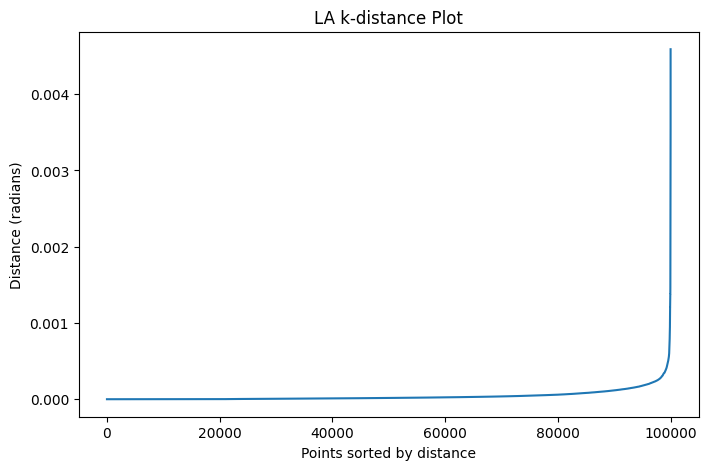

Example elbow in km: 0.7409529916820805


In [9]:
k = 20

nbrs = NearestNeighbors(n_neighbors=k, metric="haversine")
nbrs.fit(la_coords)

distances, _ = nbrs.kneighbors(la_coords)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("LA k-distance Plot")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance (radians)")
plt.show()

earth_radius_km = 6371
print("Example elbow in km:", k_distances[int(len(k_distances)*0.9)] * earth_radius_km)

In [10]:
max_eps_km = 1
max_eps_rad = max_eps_km / 6371

optics_la = OPTICS(
    min_samples=60,
    max_eps=max_eps_rad,
    metric="haversine",
    cluster_method="xi",
    xi=0.05
)

optics_la.fit(la_coords)

labels_la = optics_la.labels_

/Users/bora/Data-Mining/.venv/lib/python3.13/site-packages/sklearn/cluster/_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


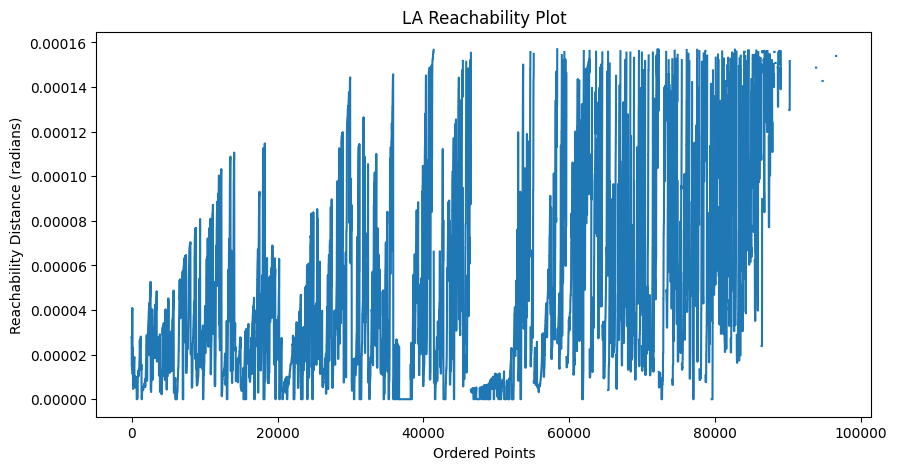

In [11]:
reachability = optics_la.reachability_[optics_la.ordering_]

plt.figure(figsize=(10,5))
plt.plot(reachability)
plt.title("LA Reachability Plot")
plt.xlabel("Ordered Points")
plt.ylabel("Reachability Distance (radians)")
plt.show()

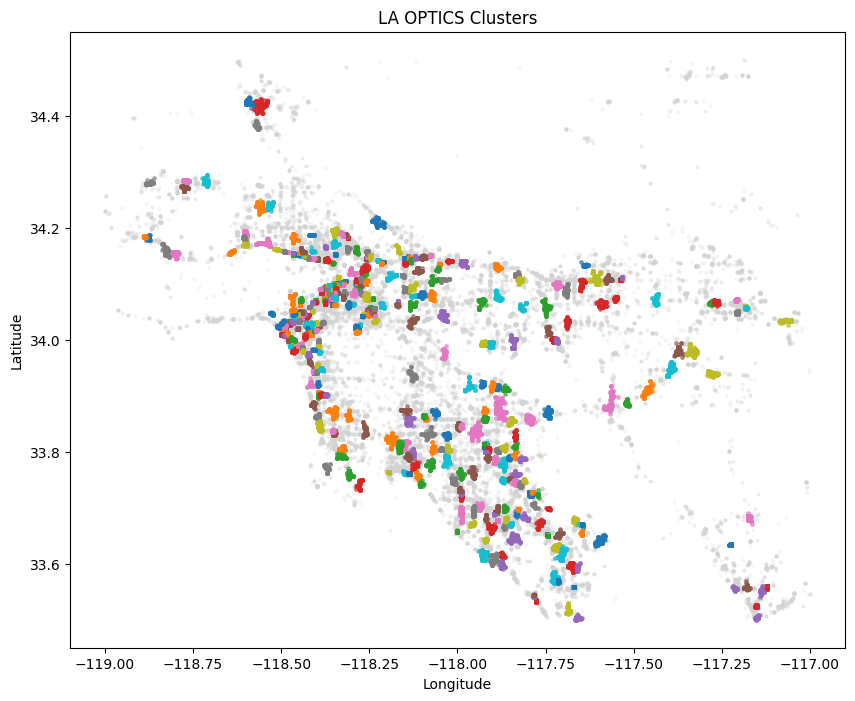

In [12]:
la_sample["cluster"] = optics_la.labels_

unique_labels = set(optics_la.labels_)

plt.figure(figsize=(10,8))

# noise plotting (low opacity)
noise_mask = la_sample["cluster"] == -1
plt.scatter(
    la_sample[noise_mask]["lon"],
    la_sample[noise_mask]["lat"],
    s=4,
    c="lightgray",
    alpha=0.15,
    label="Noise"
)

# actual clusters
for label in unique_labels:
    if label == -1:
        continue
        
    mask = la_sample["cluster"] == label
    plt.scatter(
        la_sample[mask]["lon"],
        la_sample[mask]["lat"],
        s=6,
        alpha=0.6,
        label=f"Cluster {label}"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("LA OPTICS Clusters")
plt.show()

In [13]:
labels = optics_la.labels_

# number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# number of noise points
n_noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)
print("Noise ratio:", n_noise / len(labels))

cluster_sizes = pd.Series(labels).value_counts()
cluster_sizes = cluster_sizes[cluster_sizes.index != -1]
print(cluster_sizes.describe())

Clusters: 464
Noise points: 43971
Noise ratio: 0.43971
count     464.000000
mean      120.752155
std        91.051744
min        60.000000
25%        79.000000
50%       101.000000
75%       136.250000
max      1590.000000
Name: count, dtype: float64
